In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import scintools 
# import psrsigsim as pss
from scintools.scint_sim import Simulation
import scintools.ththmod as THTH
from astropy import units as u
from astropy.coordinates import SkyCoord
from scipy.signal import peak_widths
from scipy.interpolate import griddata
from mwprop.nemod.NE2025 import ne2025

from src import dmbeat
from src.psrsigsim.signal.fb_signal import FilterBankSignal
from src.psrsigsim.pulsar.profiles import GaussProfile
from src.psrsigsim.pulsar.pulsar import Pulsar
from src.psrsigsim.ism.ism import ISM
from src.rm_sim import rm_sim

import time

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [2]:
c = SkyCoord('06 30 00 -28 34 00', unit=(u.hourangle, u.deg))
cg = c.galactic

Dk,Dv,Du,Dd = ne2025(ldeg=cg.l.deg,bdeg=cg.b.deg,dmd=34.425,ndir=1,dmd_only=False)
# ne2025?

sbw1GHz = Dv['SBW']
print(sbw1GHz) # MHz
sbw150MHz = sbw1GHz * (150/1000)**(22/5)
print(sbw150MHz)
scintime1GHz = Dv['SCINTIME']
print(scintime1GHz) # s
scintime150MHz = scintime1GHz * (150/1000)**(6/5) * (77.3/100)**(-1)
print(scintime150MHz, 'sec at 150 MHz')

mb2 = 0.773 * (150/sbw150MHz)**(5/6)
print(mb2)

screendist = Dv['DEFFSM2'] # kpc

# mb2 = 0.773 * (nu_c / delnu_d)**(5/6)

#NE2025 input: 4 parameters
   236.8691         l             (deg)                    GalacticLongitude                  
   -16.9209         b             (deg)                    GalacticLatitude                   
    34.4250         DM/D          (pc cm^{-3}_or_kpc)      Input DM or Distance               
          1         ndir          1:DM->D;-1:D->DM         Which?(DM or D)                    
#NE2025 output: 17 values
     0.4479         DIST          (kpc)                    ModelDistance                      
    34.4250         DM            (pc cm^{-3})             DispersionMeasure                  
    10.0194         DMz           (pc cm^{-3})             DM_Zcomponent                      
 7.2925e-05         SM            (kpc m^{-20/3})          ScatteringMeasure                  
 1.0165e-04         SMtau         (kpc m^{-20/3})          SM_PulseBroadening                 
 8.5411e-05         SMtheta       (kpc m^{-20/3})          SM_GalAngularBroadening         

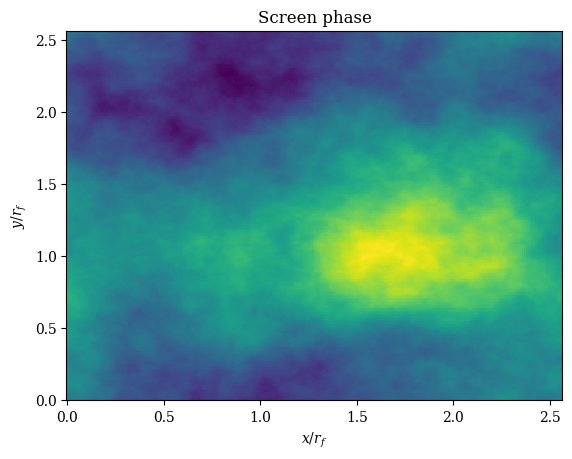

In [3]:
sim = Simulation()
sim.plot_screen()

In [4]:
# veff = ds / dt 
# assume a Fresnel scale? rF = (R/k)^(1/2) where R is distance to scattering screen and k is wavenumber 2pi/lambda
# for R = 1 kpc and lambda = 2 m (nu = 150 MHz), rF = 3.13e9 m = 3,000,000 km
# DR's suggestion is rF = 100,000 km
cf = 150 # MHz
screendist_m = screendist * 3.086e16 * 1e3 # screendist in kpc
lam = 3e8 / 150e6
print(lam, 'm wavelength')
wavenumber = 2*np.pi/lam
rfresnel_m = np.sqrt(screendist_m/wavenumber)
print(rfresnel_m/1e3, 'km Fresnel scale')

2.0 m wavelength
1288372.451048294 km Fresnel scale


dsvec [0.00059998]
ds 0.0005999817827298641 ns 8334 time 99.4745421409607


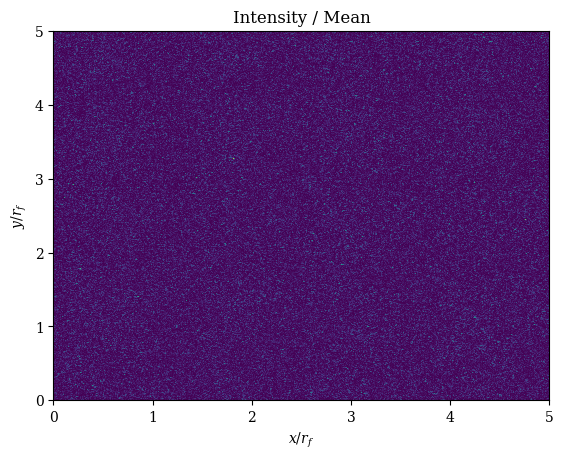

(8, 8334)
10.0


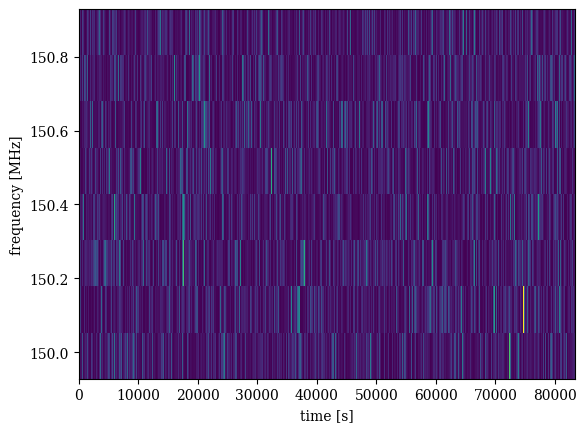

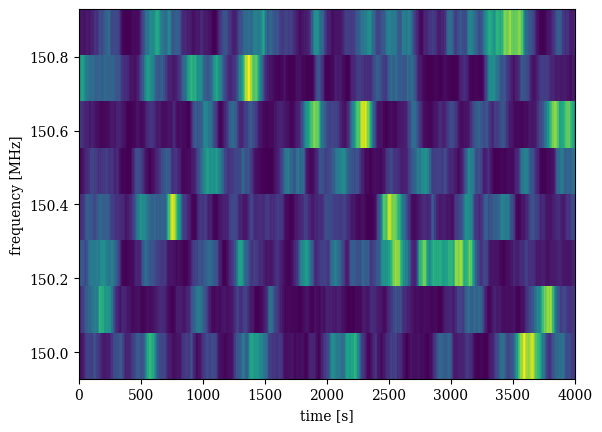

In [6]:
mb2 = 3846.6# 3846.6 # 3000  # the Born variance, which controls the strength of scattering
rfresnel = 1 # per DR: since the simulation is done in 'Fresnel units', this is the unit length and should always be 1
rfresnel_km = rfresnel_m/1e3 # in physical units of meters: 100,000 km
ar = 1  # axial ratio of anisotropy
psi = 0  # angle of velocity relative to the x-axis

dtvec = np.array([10])
#dsvec = np.array([0.001])
veff = 77.3 # km/s
dsvec_km = dtvec * veff
dsvec = dsvec_km / rfresnel_km
#dsvec_km = dsvec * rfresnel_km
#dtvec = dsvec_km / veff
print('dsvec', dsvec)

lf = 150
rf = 151
cf = (lf+rf)/2
bw = rf-lf
frac_bw = bw/cf

dlam = frac_bw  # fractional bandwidth
freq = cf # center frequency
ns = round(5*(1/dsvec[0]))  # The size of the simulation in spatial steps. Total length in refractive scales is ns * ds
# it seems like I can make the scintillation time smaller by tuning down ns
# this is because total length in refractive scales is ns * ds
nf = int(bw/(0.122))  # The number of frequency channels across the dlam fractional bandwidth

seed = 3  # The seed to generate the random phase screen, for reproducible experiments

# these settings produce ~antisymmetric dynamic spectra
# pass rectangular parameters nx, ny to save runtime

for i, ds in enumerate(dsvec):
    start = time.time()
    dt = dtvec[i]
    nx = ns*20
    sim = Simulation(mb2=mb2, rf=rfresnel, ar=ar, 
                     ds=ds, 
                     psi=psi, dlam=dlam,
                     inner=0.0001,
                     #dx=ds, dy=0.2*ds,
                    ns=ns,
                    #nx=nx,
                    #ny=ns, 
                    nf=nf, seed=seed,
                    freq=freq, 
                    dt=dt)
    end = time.time()
    print('ds',ds,'ns',ns,'time', end-start)
    dspec = sim.spi
    sim.plot_intensity()
    plt.imshow(dspec.T, aspect='auto', interpolation='none', cmap='viridis', extent=[0, ns*ds*rfresnel_km/veff, np.min(sim.freqs), np.max(sim.freqs)])
    print(dspec.T.shape)
    print(ns*ds*rfresnel_km/veff/dspec.T.shape[1])
    plt.xlabel('time [s]')
    plt.ylabel('frequency [MHz]')
    #plt.colorbar('scintle amplification factor')
    plt.show()
    ntsamp = 400
    plt.imshow(dspec.T[:,:ntsamp], aspect='auto', interpolation='none', cmap='viridis', extent=[0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1], np.min(sim.freqs), np.max(sim.freqs)])
    plt.xlabel('time [s]')
    plt.ylabel('frequency [MHz]')
    #plt.colorbar('scintle amplification factor')
    plt.show()
# per NE2025, scattering screen is 38% of the way to the pulsar
# s0 = 1-0.38
# rf = s0 * sqrt(vc/vd)

# ACFs over band to verify that scintools is incorporating the 6/5 power law

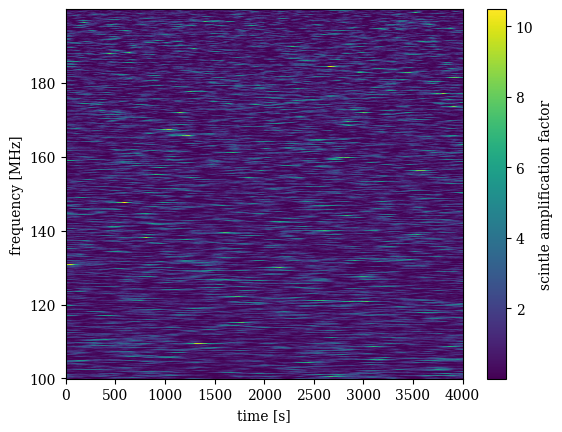

In [101]:
plt.imshow(dspec.T[:,:ntsamp], aspect='auto', interpolation='none', cmap='viridis', extent=[0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1], np.min(sim.freqs), np.max(sim.freqs)])
plt.xlabel('time [s]')
plt.ylabel('frequency [MHz]')
plt.colorbar(label='scintle amplification factor', ax=plt.gca())
plt.show()

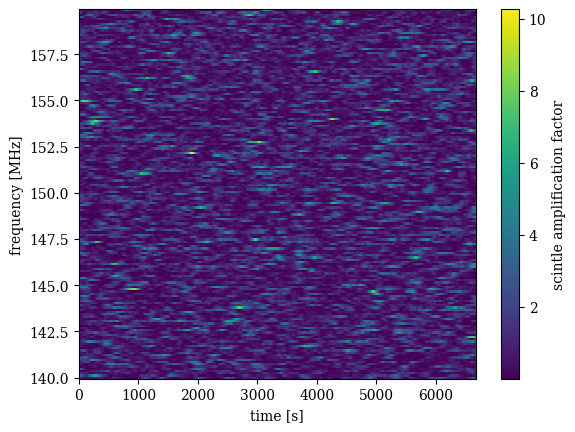

In [9]:
plt.imshow(dspec.T[:,:ntsamp], aspect='auto', interpolation='none', cmap='viridis', extent=[0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1], np.min(sim.freqs), np.max(sim.freqs)])
plt.xlabel('time [s]')
plt.ylabel('frequency [MHz]')
plt.colorbar(label='scintle amplification factor', ax=plt.gca())
plt.show()

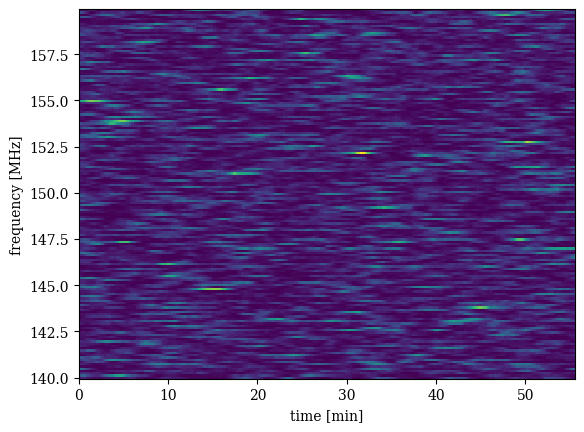

In [16]:
ntsamp = 200
plt.imshow(dspec.T[:,:ntsamp], aspect='auto', interpolation='none', cmap='viridis', extent=[0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1] / 60, np.min(sim.freqs), np.max(sim.freqs)])
plt.xlabel('time [min]')
plt.ylabel('frequency [MHz]')
#plt.colorbar('scintle amplification factor')
plt.show()

16.66717271731299


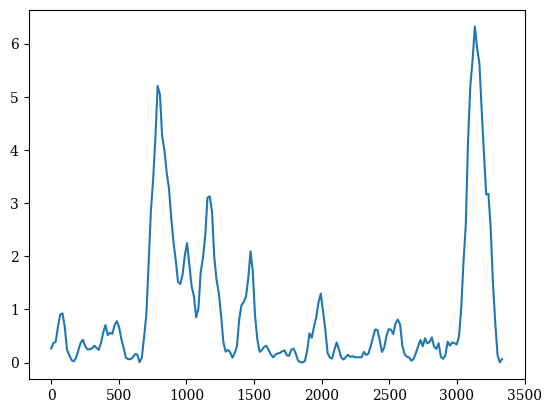

91.57476269137669


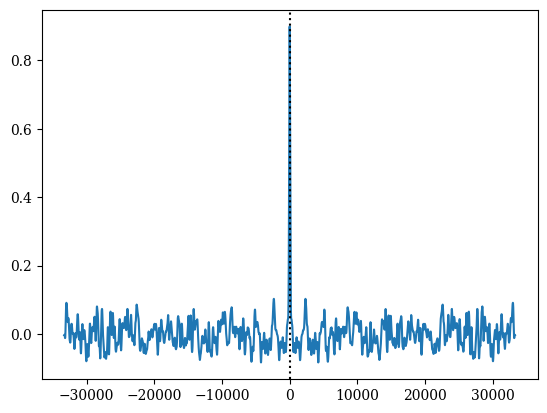

In [186]:
def acf(vec):
    a = []
    for i in range(len(vec)):
        rollvec = np.roll(vec, i)
        a.append(np.dot(vec, rollvec)/len(vec))
    return np.array(a)
def fwhm(x, y):
    w = peak_widths(y, [np.argmax(y)], rel_height=0.5)[0]
    return w

xxx = np.linspace(0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1], ntsamp)
del_t = ns*ds*rfresnel_km/veff * 1/dspec.T.shape[1]
print(del_t)
plt.plot(xxx, dspec.T[0,:ntsamp])
plt.show()
aaa = acf(dspec.T[0])
plt.plot((np.arange(len(aaa))-np.mean(np.arange(len(aaa))))*del_t, np.roll(aaa, len(aaa)//2)-np.mean(aaa))
plt.axvline(0, ls=':', c='k')
print(fwhm((np.arange(len(aaa))-np.mean(np.arange(len(aaa))))*del_t, np.roll(aaa, len(aaa)//2)-np.mean(aaa))[0]*del_t/2)
plt.show()

fff = np.linspace(lf, rf, nf)
acfvec = []
for i in range(nf):
    xxx = np.linspace(0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1], ntsamp)
    del_t = ns*ds*rfresnel_km/veff * 1/dspec.T.shape[1]
    aaa = acf(dspec.T[i])
    acfvec.append(fwhm((np.arange(len(aaa))-np.mean(np.arange(len(aaa))))*del_t, np.roll(aaa, len(aaa)//2)-np.mean(aaa))[0]*del_t/2)

1.2591522284681116
0.017578704417965805


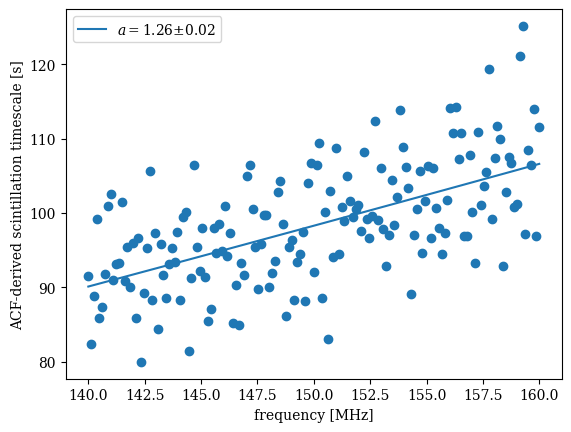

In [194]:
acfvec = np.array(acfvec)
plt.scatter(fff, acfvec)
flog = np.log10(fff*1e6)
alog = np.log10(acfvec)
cvec, V = np.polyfit(flog, alog, deg=1, cov=True)
m = cvec[0]
b = cvec[1]
afit = np.polyval([m, b], flog)
print(m)
print(V[0,0])
plt.plot(fff, 10**afit, label=f'$a = ${m:.3}$\pm${V[0,0]:.1}')
plt.xlabel('frequency [MHz]')
plt.ylabel('ACF-derived scintillation timescale [s]')
plt.legend()
plt.show()

In [ ]:
### ADD IN DM BEATING AND RM EFFECTS

nf 819
6e-05
98% dispersed in 8.156 seconds.

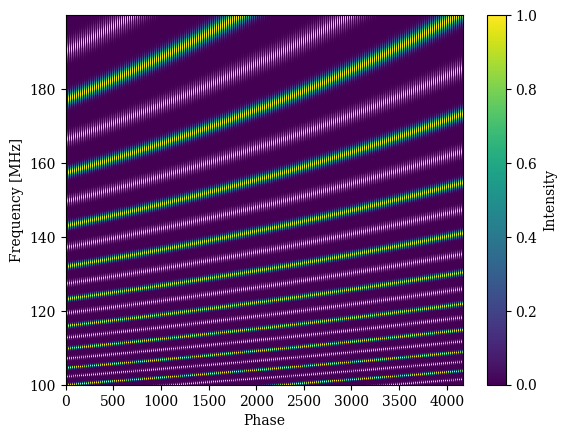

In [102]:
# Define our signal variables.
f0 = cf # center observing frequecy in MHz
# bw defined above
Nf = nf # number of frequency channels
print('nf', nf)
f_samp = 0.0001 * 0.6 # sample rate of data in MHz (here 0.6554 ms for size purposes)
#f_samp = 1e6/dtvec[0]
print(f_samp)
# Now we define our signal
signal_1 = FilterBankSignal(fcent = f0, bandwidth = bw, Nsubband=Nf, sample_rate=f_samp, fold = False)
# We define the Guassian profile
gauss_prof = GaussProfile(peak = 0.5, width = 0.05, amp = 1.0)
# We want to use 2048 phase bins and just one frequency channel for this test.
gauss_prof.init_profiles(2048, Nchan = 1)

# Define the values needed for the puslar
period = 1.2 # pulse period of our simulated pulsar, here one second
Smean = 0.100 # The mean flux of the pulsar, here 100 mJy (note that this is fairly bright for a pulsar)
psr_name = "J0630-2834" # The name of our simulated pulsar
# psr_name_b = 'B0628-28'
# Now we define the pulsar
pulsar_1 = Pulsar(period, Smean, profiles=gauss_prof, name = psr_name)

# Define the dispersion measure
dm = 34.0 #34.0 # pc cm^-3
# And define the ISM object, note that this class takes no initial arguements
ism_1 = ISM()

# define the observation length
obslen = 5000.0 # seconds
pulsar_1.make_pulses(signal_1, tobs = obslen)
ism_1.disperse(signal_1, dm)

phases = np.linspace(0, obslen/period, len(signal_1.data[0,:]))
plt.figure()
plt.imshow(signal_1.data, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value])
plt.ylabel("Frequency [MHz]")
plt.xlabel("Phase")
plt.colorbar(label = "Intensity")
#plt.xlim(0,10)

plt.show()

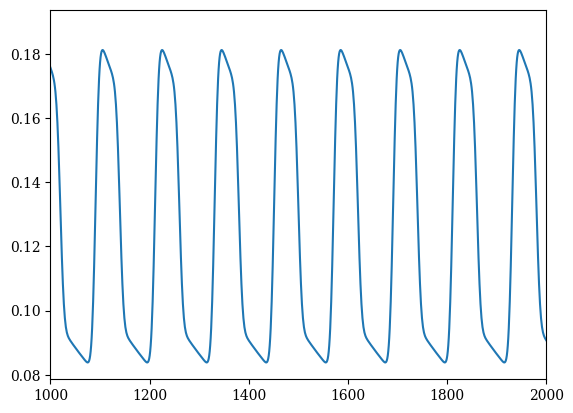

In [31]:
plt.plot(np.average(signal_1.data, axis=0))
plt.xlim(1000,2000)
plt.show()

In [103]:
#dm_dynspec = dmbeat.dmbeat(fstart=140, fstop=160, df=0.12345, dt=10, tobs=500, P=1.2, D=0.05, DM=34, psr='J0630-2834')
dm_dynspec = dmbeat.downbin(signal_1, phases, fbin=bw/nf, tbin=16.66667)

818.9999999999972 1.0000000000000036 299.999940000012 1000.0002000000001


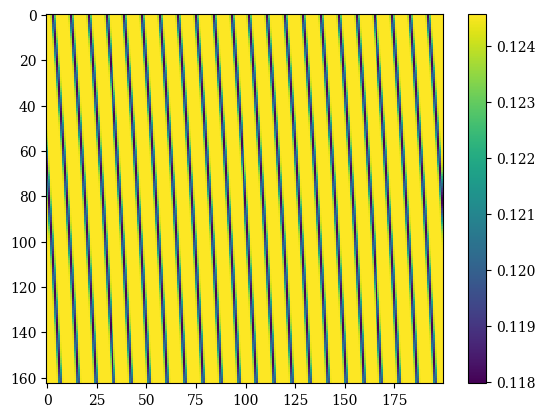

In [87]:
plt.imshow(dm_dynspec[:,100:], aspect='auto', interpolation='none')
plt.colorbar()
plt.show()

In [36]:
print(len(sim.freqs))
print(sim.freqs[1]-sim.freqs[0])

163
0.12345679012344135


In [104]:
ntsamp=200
print(dm_dynspec.shape)
print(dspec.T[:,:ntsamp].shape)

(819, 300)
(819, 200)


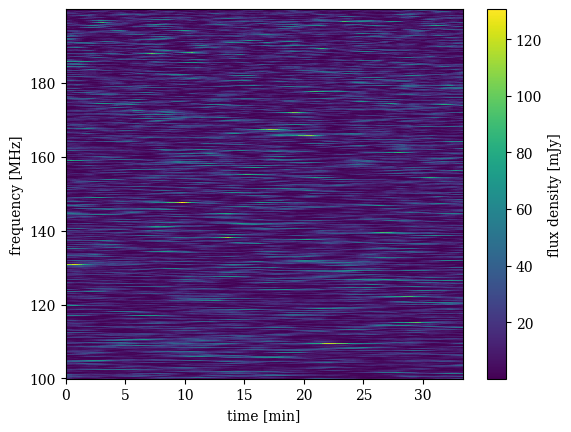

In [105]:
dmscint = dm_dynspec[:,100:]*dspec.T[:,:ntsamp] * 100

plt.imshow(dmscint, aspect='auto', interpolation='none',
           extent=[0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1] / 60, np.min(sim.freqs), np.max(sim.freqs)])
# factor of 100 fixes units
# pulsar peak amplitude is ~100 mJy
# this is simulated as '1'
# factor of 100 takes '1' --> 100 mJy
plt.colorbar(label='flux density [mJy]')
plt.xlabel('time [min]')
plt.ylabel('frequency [MHz]')
plt.show()

In [106]:
freq = signal_1.dat_freq.value * 1e6
RM = 45.78

full_stokes = rm_sim(data=dmscint, freq=sim.freqs * 1e6,
           linpol=0.6, cirpol=0., polangle=80,
           RM=45.78)
I = full_stokes[0]
Q = full_stokes[1]
U = full_stokes[2]
V = full_stokes[3]

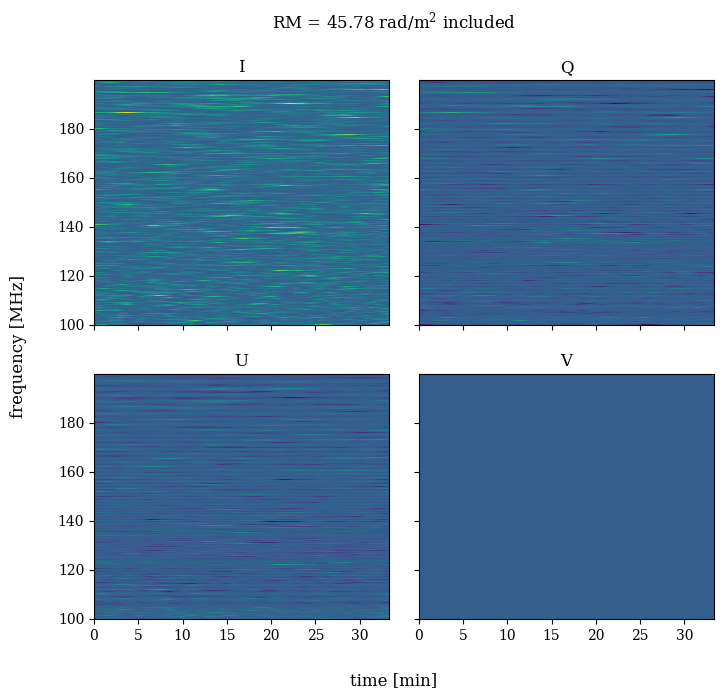

In [107]:
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(8,7))
cmap='viridis'
RM = 45.78
ax[0,0].imshow(I, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1] / 60, 
                     signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[0,0].set_title('I')
ax[0,1].imshow(Q, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1] / 60,
                      signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[0,1].set_title('Q')
ax[1,0].imshow(U, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1] / 60,
                      signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[1,0].set_title('U')
ax[1,1].imshow(V, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1] / 60,
                      signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(full_stokes), vmax=np.max(full_stokes), cmap=cmap)
ax[1,1].set_title('V')
#plt.xlim(0,10)
plt.subplots_adjust(hspace=0.2, wspace=0.1)
fig.supxlabel('time [min]')
fig.supylabel('frequency [MHz]')
fig.suptitle(f'RM = {RM} rad/m$^2$ included')
plt.show()

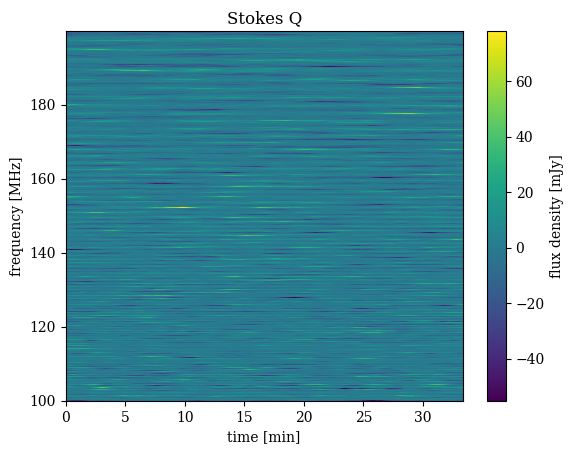

In [108]:
plt.imshow(Q, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [0, ns*ds*rfresnel_km/veff * ntsamp/dspec.T.shape[1] / 60,
                      signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value],
           vmin = np.min(Q), vmax=np.max(Q), cmap=cmap)
plt.xlabel('time [min]')
plt.ylabel('frequency [MHz]')
plt.title('Stokes Q')
plt.colorbar(label='flux density [mJy]')
plt.show()

500
300


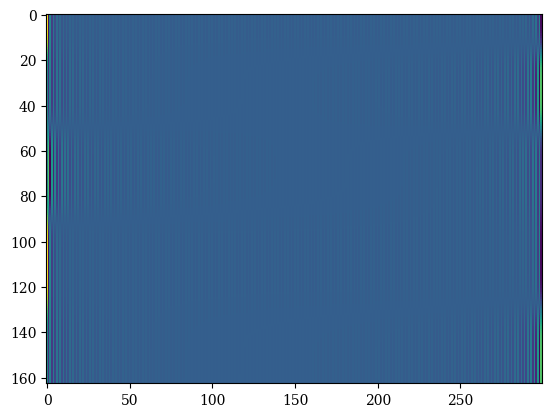

In [ ]:
from scipy.signal import resample

old_dt = 10
new_dt = dtvec[0] # 16.667 ish

new_ntime = round(dm_dynspec.shape[1] * old_dt/new_dt)
print(dm_dynspec.shape[1])
print(new_ntime)

dynspec_resampled = resample(dm_dynspec, new_ntime, axis=1)

plt.imshow(dynspec_resampled, aspect='auto', interpolation='none')
#plt.xlim(0, 100)
plt.show()